
[mr.nii.gz] 统计参数:
----------------------------------------
1. 张量维度 (Tensor Shape) : (231, 244, 204)
2. 体素间距 (Voxel Spacing): (1.0, 1.0, 1.0) mm
3. 内存数据类型 (Data Type): float64
4. 仿射矩阵 (Affine Matrix):
[[  -1.    0.    0.  118.]
 [   0.   -1.    0.   71.]
 [   0.    0.    1. -124.]
 [   0.    0.    0.    1.]]
5. 数值极值 (Value Range)  : Min = 0.00, Max = 3000.00
----------------------------------------


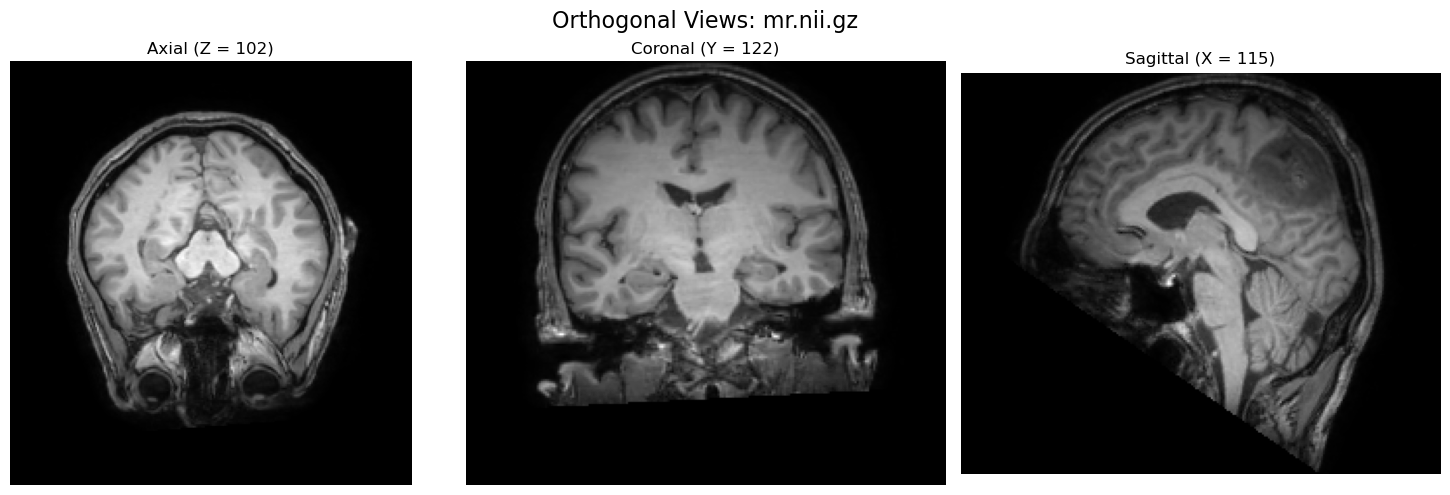


[ct.nii.gz] 统计参数:
----------------------------------------
1. 张量维度 (Tensor Shape) : (231, 244, 204)
2. 体素间距 (Voxel Spacing): (1.0, 1.0, 1.0) mm
3. 内存数据类型 (Data Type): float64
4. 仿射矩阵 (Affine Matrix):
[[  -1.    0.    0.  118.]
 [   0.   -1.    0.   71.]
 [   0.    0.    1. -124.]
 [   0.    0.    0.    1.]]
5. 数值极值 (Value Range)  : Min = -1023.00, Max = 1874.00
----------------------------------------


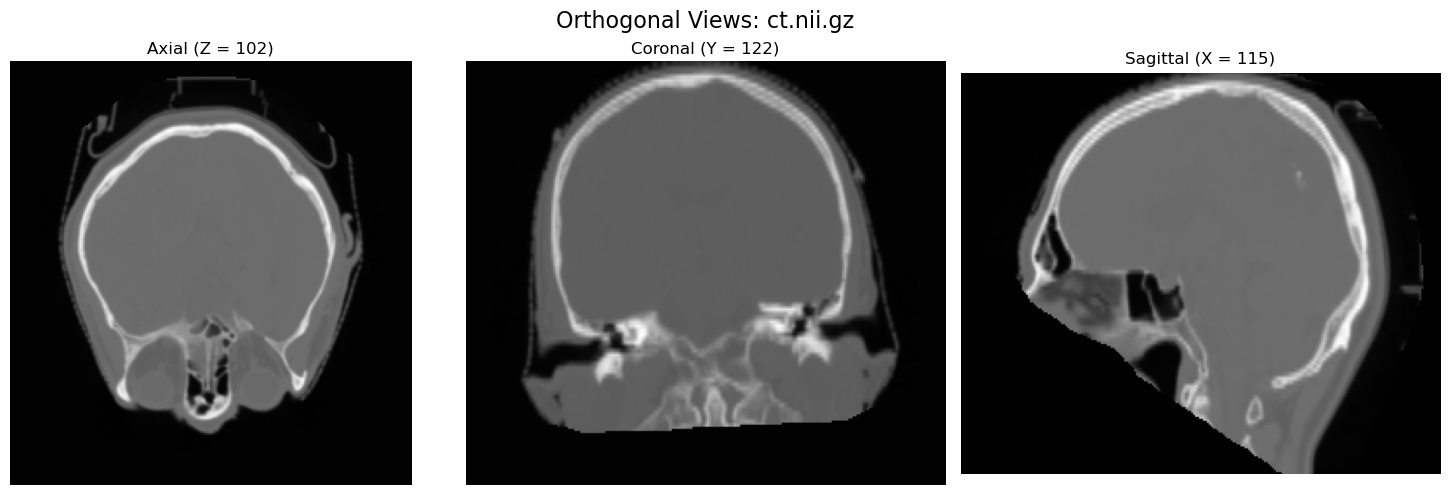

In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_visualize_nifti(file_path):
    if not os.path.exists(file_path):
        print(f"Error: 找不到文件 {file_path}")
        return

    # 1. 解析 NIfTI 对象
    # nib.load 不会将整个张量载入内存，仅加载 header 和 proxy 代理
    img = nib.load(file_path)
    
    # 2. 将数据实例化为 NumPy Ndarray
    data = img.get_fdata()
    header = img.header

    # ==========================================
    # 模块 A: 打印几何与数值参数 (Parameter Extraction)
    # ==========================================
    print(f"\n[{os.path.basename(file_path)}] 统计参数:")
    print("-" * 40)
    # 物理维度 (X, Y, Z) 的离散体素网格大小
    print(f"1. 张量维度 (Tensor Shape) : {data.shape}") 
    # 对应的连续物理空间大小 (毫米)
    print(f"2. 体素间距 (Voxel Spacing): {header.get_zooms()} mm") 
    print(f"3. 内存数据类型 (Data Type): {data.dtype}")
    # 描述体素索引坐标系 (i, j, k) 到真实世界参考系 (x, y, z) 的线性映射
    print(f"4. 仿射矩阵 (Affine Matrix):\n{img.affine}")
    # 全局最大最小值，用于确定归一化窗口 (Window Level/Width)
    print(f"5. 数值极值 (Value Range)  : Min = {np.min(data):.2f}, Max = {np.max(data):.2f}")
    print("-" * 40)

    # ==========================================
    # 模块 B: 提取并渲染正交切片 (Orthogonal Visualization)
    # ==========================================
    # 获取张量空间中心的索引坐标
    x_mid = data.shape[0] // 2
    y_mid = data.shape[1] // 2
    z_mid = data.shape[2] // 2

    # 提取三大正交面 (Axial, Coronal, Sagittal)
    # 注意：在医学图像坐标系中，提取切片后通常需要旋转90度 (np.rot90) 以符合放射学阅片习惯
    slice_axial = np.rot90(data[:, :, z_mid])       # 轴状面 (XY)
    slice_coronal = np.rot90(data[:, y_mid, :])     # 冠状面 (XZ)
    slice_sagittal = np.rot90(data[x_mid, :, :])    # 矢状面 (YZ)

    # 绘图逻辑
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Orthogonal Views: {os.path.basename(file_path)}', fontsize=16)

    # 渲染参数：如果可视化的是 CT，vmin/vmax 可手动调整为骨骼或软组织窗
    axes[0].imshow(slice_axial, cmap='gray')
    axes[0].set_title(f'Axial (Z = {z_mid})')
    axes[0].axis('off')

    axes[1].imshow(slice_coronal, cmap='gray')
    axes[1].set_title(f'Coronal (Y = {y_mid})')
    axes[1].axis('off')

    axes[2].imshow(slice_sagittal, cmap='gray')
    axes[2].set_title(f'Sagittal (X = {x_mid})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 配置你的数据路径
    mr_path = '/home/ljc/code/PaBoT-main/brain/1BA001/mr.nii.gz'
    ct_path = '/home/ljc/code/PaBoT-main/brain/1BA001/ct.nii.gz'

    # 执行分析 (如果处于无图形界面的服务器中，注释掉 plt.show()，改用 plt.savefig('output.png'))
    analyze_and_visualize_nifti(mr_path)
    analyze_and_visualize_nifti(ct_path)

In [2]:
import os
from collections import Counter

def analyze_dataset_structure(target_path):
    """
    扫描目标路径，统计有效子目录总数，并按前缀（如 1BA, 1BB）输出分布频率。
    """
    # 1. 路径合法性断言
    if not os.path.exists(target_path):
        print(f"Error: 物理路径不可达 -> {target_path}")
        return

    # 2. 获取所有节点并执行目录过滤
    # 排除隐藏文件或 .nii.gz 等非目录实体
    subdirs = [
        d for d in os.listdir(target_path) 
        if os.path.isdir(os.path.join(target_path, d))
    ]
    
    total_folders = len(subdirs)
    
    if total_folders == 0:
        print(f"路径 {target_path} 下不存在任何子文件夹。")
        return

    # 3. 提取前缀建立映射表 (切片前 3 个字符)
    # 例如将 '1BA336' 映射为键 '1BA'
    prefixes = [folder[:3] for folder in subdirs]
    distribution = Counter(prefixes)

    # 4. 终端输出结果
    print(f"=== 数据集目录统计 ===")
    print(f"扫描路径: {target_path}")
    print(f"有效病例文件夹总数: {total_folders}\n")
    
    print("--- 频率分布 (按中心/类别) ---")
    for prefix, count in sorted(distribution.items()):
        print(f"类别 [{prefix}]: {count} 例")

if __name__ == "__main__":
    # 配置你的目标路径
    # 如果你要统计 brain 目录下的所有病例，使用此路径：
    dataset_path = "/home/ljc/code/PaBoT-main/brain/"
    
    analyze_dataset_structure(dataset_path)

=== 数据集目录统计 ===
扫描路径: /home/ljc/code/PaBoT-main/brain/
有效病例文件夹总数: 181

--- 频率分布 (按中心/类别) ---
类别 [1BA]: 60 例
类别 [1BB]: 60 例
类别 [1BC]: 60 例
类别 [ove]: 1 例
